# Code Reviewer Thesis — Experiment Findings

This notebook loads **Phase 1–4** results from this repo and presents the full pipeline: dataset splits (Phase 1), validation and model choice (Phase 2), hybrid config (Phase 3), and evaluation metrics and hypotheses (Phase 4).

**Data:** DiverseVul C/C++ test set. **Models:** ML (CodeBERT), PaC (Semgrep with p/c + p/cwe-top-25 + custom CWE rules), Hybrid (α·ML + β·PaC with tuned thresholds).

In [1]:
import json
import os

import pandas as pd

# Paths: run from repo root or from notebooks/
cwd = os.getcwd()
PROJECT_ROOT = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
PHASE3_RESULTS_DIR = os.path.join(PROJECT_ROOT, 'phase3_results')

# Phase 1
splits_path = os.path.join(DATA_DIR, 'splits.json')

# Phase 2
phase2_path = os.path.join(RESULTS_DIR, 'phase2_validation_report.json')
if not os.path.isfile(phase2_path):
    phase2_path = os.path.join(PHASE3_RESULTS_DIR, 'phase2_validation_report.json')

# Phase 3 / 4
report_path = os.path.join(RESULTS_DIR, 'phase4_evaluation_report.json')
if not os.path.isfile(report_path):
    report_path = os.path.join(PHASE3_RESULTS_DIR, 'phase4_evaluation_report.json')
config_path = os.path.join(RESULTS_DIR, 'phase3_hybrid_config.json')
if not os.path.isfile(config_path):
    config_path = os.path.join(PHASE3_RESULTS_DIR, 'phase3_hybrid_config.json')
csv_path = os.path.join(RESULTS_DIR, 'phase3_experiment_results.csv')
if not os.path.isfile(csv_path):
    csv_path = os.path.join(PHASE3_RESULTS_DIR, 'phase3_experiment_results.csv')

with open(report_path) as f:
    report = json.load(f)
with open(config_path) as f:
    hybrid_config = json.load(f)
phase2_report = None
if os.path.isfile(phase2_path):
    with open(phase2_path) as f:
        phase2_report = json.load(f)
splits = None
if os.path.isfile(splits_path):
    with open(splits_path) as f:
        splits = json.load(f)

print('Loaded Phase 4:', report_path)
print('Loaded Phase 3 config:', config_path)
if phase2_report:
    print('Loaded Phase 2:', phase2_path)
if splits:
    print('Loaded Phase 1 splits:', splits_path)

Loaded Phase 4: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase4_evaluation_report.json
Loaded Phase 3 config: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase3_hybrid_config.json
Loaded Phase 2: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase2_validation_report.json
Loaded Phase 1 splits: /Users/jededisondonaire/jed/code-reviewer-thesis/data/splits.json


## 1. Phase 1 — Dataset (splits)

Train / validation / test split sizes from `data/splits.json` (DiverseVul C/C++ curated dataset).

In [2]:
if splits:
    split_counts = {k: len(v) for k, v in splits.items()}
    total = sum(split_counts.values())
    pd.DataFrame([split_counts]).T.rename(columns={0: 'count'}).assign(pct=lambda d: (d['count'] / total * 100).round(1))
else:
    print('Phase 1 splits not found. Run phase1_dataset.py or copy data/splits.json into the repo.')

## 2. Phase 2 — Validation (model choice)

We load **F1, Precision, and Recall** on the validation set for both trained models (CodeBERT and Random Forest) from `phase2_validation_report.json`. The model with the **higher validation F1** is selected for Phase 3 (ML-only and Hybrid).

In [3]:
if phase2_report:
    selected = phase2_report.get('selected_model', '?')
    df_phase2 = None
    rows = []
    for name in ('codebert', 'random_forest'):
        if name not in phase2_report:
            continue
        m = phase2_report[name]
        rows.append({
            'Model': name,
            'F1': m.get('eval_f1'),
            'Precision': m.get('eval_precision'),
            'Recall': m.get('eval_recall'),
        })
    if rows:
        df_phase2 = pd.DataFrame(rows).set_index('Model').round(4)
    print('Selected model:', selected)
    f1_cb = phase2_report.get('codebert', {}).get('eval_f1')
    f1_rf = phase2_report.get('random_forest', {}).get('eval_f1')
    if f1_cb is not None and f1_rf is not None:
        print('Why CodeBERT wins: validation F1 (%.4f) > Random Forest F1 (%.4f). Selection criterion is higher F1.' % (f1_cb, f1_rf))
    df_phase2
else:
    print('Phase 2 report not found. Run phase2_train.py or copy phase2_validation_report.json into results/ or phase3_results/.')

Selected model: codebert
Why CodeBERT wins: validation F1 (0.1890) > Random Forest F1 (0.0240). Selection criterion is higher F1.


## 3. Phase 3 — Hybrid configuration

Validation tuning chose α (ML weight) and β (PaC weight) and thresholds for Block/Review.

**Why CodeBERT wins:** Selection is by **validation F1**. CodeBERT has much higher F1 and recall than the Random Forest baseline (which uses only static metrics from lizard). On imbalanced vulnerability data, F1 balances precision and recall; CodeBERT’s higher recall (catching more true defects) without collapsing precision makes it the better choice for the ML channel in Phase 3.

In [4]:
pd.DataFrame([hybrid_config]).T.rename(columns={0: 'value'})

,value
alpha,0.750000
beta,0.250000
t_block,0.400000
t_review,0.100000
val_ml_min,0.093220
val_ml_max,0.536837
val_pac_min,0.000000
val_pac_max,1.000000


**Interpretation:** If β=0, the hybrid is effectively ML-only (PaC score is ignored in the risk).

## 4. Phase 4 — Primary metrics (Block decision)

Precision, Recall, F1 for ML-Only, PaC-Only, and Hybrid.

In [5]:
pm = report['primary_metrics']
df_metrics = pd.DataFrame(pm).T
df_metrics = df_metrics.rename(columns={'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1'})
df_metrics.round(4)

,Precision,Recall,F1
ML_Only,0.1272,0.3459,0.1860
PaC_Only,0.2059,0.0326,0.0563
Hybrid,0.1272,0.3459,0.1860


(0.0, 1.0)

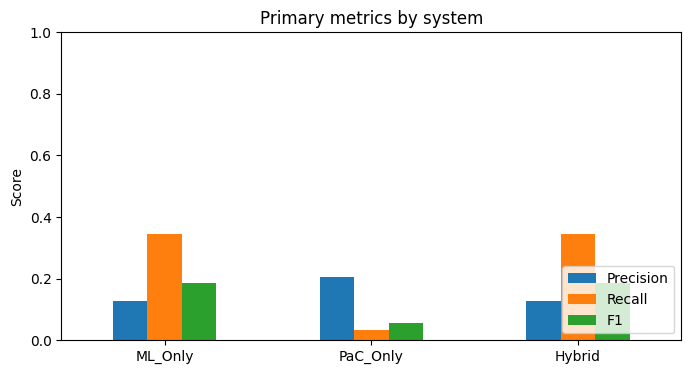

In [6]:
%matplotlib inline
ax = df_metrics[['Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_ylabel('Score')
ax.set_title('Primary metrics by system')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)

## 5. Phase 4 — ROC AUC

In [7]:
auc = report['roc_auc']
pd.DataFrame([auc]).T.rename(columns={0: 'AUC'}).round(4)

,AUC
ML_Only,0.7044
PaC_Only,0.5515
Hybrid,0.7086


## 6. Phase 4 — McNemar (Hybrid vs ML, Hybrid vs PaC)

p-value and odds ratio for paired Block decisions.

In [8]:
mcn = report['mcnemar']
mcn_df = pd.DataFrame({
    'Comparison': list(mcn.keys()),
    'McNemar p': [mcn[k]['mcnemar_p'] for k in mcn],
    'Odds ratio': [mcn[k]['odds_ratio'] for k in mcn],
})
mcn_df.round(4)

,Comparison,McNemar p,Odds ratio
0,Hybrid_vs_ML,0.1573,inf
1,Hybrid_vs_PaC,0.0000,6.1332


## 7. Phase 4 — Hypotheses

In [9]:
hyp = report['hypotheses']
rows = []
for k, v in hyp.items():
    rows.append({'Hypothesis': k, 'Statement': v.get('statement', ''), 'Supported': v.get('supported', None)})
pd.DataFrame(rows)

,Hypothesis,Statement,Supported
0,H1,Hybrid F1 > ML-Only and > PaC-Only,False
1,H2,Hybrid Recall > PaC-Only Recall,True
2,H3,Hybrid Precision > ML-Only Precision,False


## 8. Experiment data snapshot (optional)

Label distribution and PaC score distribution from the Phase 3 CSV (sample if large).

In [10]:
if os.path.isfile(csv_path):
    df = pd.read_csv(csv_path, usecols=['label', 'ml_confidence', 'pac_score', 'decision_ml', 'decision_pac', 'decision_hybrid'], nrows=100_000)
    print('Sample size:', len(df))
    print('Label distribution:')
    print(df['label'].value_counts())
    print('\nPaC score > 0:', (df['pac_score'] > 0).sum(), f'({100 * (df["pac_score"] > 0).mean():.1f}%)')
    print('\nDecision counts (Block=2):')
    for col in ['decision_ml', 'decision_pac', 'decision_hybrid']:
        if col in df.columns:
            print(f'  {col}:', df[col].value_counts().to_dict())
else:
    print('Phase 3 CSV not found at', csv_path)

Sample size: 33050
Label distribution:
label
0    31119
1     1931
Name: count, dtype: int64

PaC score > 0: 3149 (9.5%)

Decision counts (Block=2):
  decision_ml: {0: 21404, 1: 6395, 2: 5251}
  decision_pac: {0: 29901, 1: 2843, 2: 306}
  decision_hybrid: {0: 26668, 2: 5253, 1: 1129}


## 9. Summary / findings

- **PaC** has non-zero F1 (custom CWE rules + p/c + p/cwe-top-25); precision is higher than ML but recall is low.
- **Hybrid** uses score normalization (val min/max) and optional min PaC weight; check Section 3 for α, β (e.g. α=0.75, β=0.25 gives a true combination). When β>0, Hybrid ROC AUC can be slightly above ML even if Block F1 is similar.
- **H2** (Hybrid recall > PaC recall) is supported; **H1** (Hybrid F1 > both) and **H3** (Hybrid precision > ML) depend on the run.
- For the thesis: report primary metrics, McNemar, and hypotheses; discuss the role of normalization and min policy weight in making the hybrid a true ML+PaC combination.